# Semana 13 — Ejemplo Aplicado: Regresión de Poisson en Datos de Conteo
## Modelos de Análisis Estadístico | Universidad de los Andes
### Prof. Alejandra Tabares

---

## Contexto

Este cuaderno presenta un **flujo de trabajo aplicado completo** para el modelado de datos de conteo, inspirado en el clásico conjunto de datos *Biochemists* (Long & Freese), pero simulado aquí para que el cuaderno sea completamente autónomo.

**Pregunta de investigación:** ¿Qué factores predicen el número de artículos publicados por bioquímicos doctorales durante los últimos tres años de su programa doctoral?

**Variable de resultado:** `articles` — número de publicaciones (entero no negativo).

**Predictores:**

| Variable | Descripción |
|----------|-------------|
| `female` | Género (1 = mujer, 0 = hombre) |
| `married` | Estado civil (1 = casado/a, 0 = no casado/a) |
| `children` | Número de hijos menores de 5 años |
| `prestige` | Puntaje de prestigio del programa doctoral (continuo, estandarizado) |
| `mentor_articles` | Número de artículos publicados por el director de tesis |

**Flujo de trabajo:**
1. Simulación y descripción de datos
2. Análisis Exploratorio de Datos (EDA)
3. Regresión de Poisson: ajuste e interpretación
4. Diagnósticos de residuales
5. Prueba de sobredispersión
6. Regresión Binomial Negativa como alternativa
7. Comparación de modelos
8. Conclusiones

In [1]:
# ── Importaciones ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

np.random.seed(2026)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Entorno listo.')

Entorno listo.


---

## Paso 1: Simulación de Datos

Simulamos 915 estudiantes de doctorado (coincidiendo con el tamaño original del conjunto de datos Biochemists) a partir del siguiente proceso generador de datos:

$$\log(\mu_i) = 0.30 - 0.20 \cdot \text{female}_i + 0.10 \cdot \text{married}_i - 0.15 \cdot \text{children}_i + 0.15 \cdot \text{prestige}_i + 0.025 \cdot \text{mentor\_articles}_i$$

Los conteos se extraen de una distribución **Binomial Negativa** (dispersión $\alpha = 0.5$) para introducir sobredispersión realista.

In [2]:
n = 915

# ── Predictores ───────────────────────────────────────────────────────────────
female          = np.random.binomial(1, 0.46, n)
married         = np.random.binomial(1, 0.66, n)
children        = np.random.poisson(0.5, n)           # principalmente 0, 1, 2
prestige        = np.random.normal(0, 1, n)            # puntaje estandarizado
mentor_articles = np.random.negative_binomial(3, 0.3, n)  # sesgado a la derecha

# ── Log-media verdadera ───────────────────────────────────────────────────────
log_mu = (0.30
          - 0.20 * female
          + 0.10 * married
          - 0.15 * children
          + 0.15 * prestige
          + 0.025 * mentor_articles)
mu_true = np.exp(log_mu)

# ── Conteos sobredispersos (Binomial Negativa con α = 0.5) ────────────────────
alpha_true = 0.5
r_nb = 1.0 / alpha_true
p_nb = r_nb / (r_nb + mu_true)
articles = np.random.negative_binomial(r_nb, p_nb)

# ── Construir DataFrame ───────────────────────────────────────────────────────
df = pd.DataFrame({
    'articles':        articles,
    'female':          female,
    'married':         married,
    'children':        children,
    'prestige':        prestige,
    'mentor_articles': mentor_articles
})

print(f'Conjunto de datos: {df.shape[0]} observaciones, {df.shape[1]} variables')
print()
print(df.head(10))

Conjunto de datos: 915 observaciones, 6 variables

   articles  female  married  children  prestige  mentor_articles
0         1       0        0         1  0.697852                4
1         1       0        1         0  0.998768               11
2         2       1        1         1 -1.498815                3
3         0       0        0         0  0.688178                6
4         0       0        1         2  0.837380                6
5         1       1        0         0  0.630176                0
6         2       0        0         1 -1.294034                4
7         0       1        1         1 -0.694857                7
8         1       1        0         0  0.592543                3
9         0       1        0         0  0.078716                1


---

## Paso 2: Análisis Exploratorio de Datos (EDA)

Antes de ajustar cualquier modelo examinamos:
- La distribución del resultado (`articles`).
- Si media ≈ varianza (equidispersión de Poisson).
- Relaciones entre los predictores y el resultado.

In [3]:
# ── Estadísticas descriptivas ──────────────────────────────────────────────────
desc = df.describe().T
print(desc.round(3).to_string())

                 count   mean    std    min    25%    50%     75%     max
articles         915.0  1.598  1.740  0.000  0.000  1.000   2.000  12.000
female           915.0  0.478  0.500  0.000  0.000  0.000   1.000   1.000
married          915.0  0.651  0.477  0.000  0.000  1.000   1.000   1.000
children         915.0  0.486  0.685  0.000  0.000  0.000   1.000   4.000
prestige         915.0  0.010  1.011 -3.511 -0.667  0.035   0.686   3.274
mentor_articles  915.0  7.121  4.765  0.000  4.000  6.000  10.000  39.000


In [4]:
# ── Tabla de frecuencias del resultado ────────────────────────────────────────
freq = df['articles'].value_counts().sort_index()
print('Tabla de frecuencias — artículos publicados:')
print(pd.DataFrame({'conteo': freq, 'pct': (freq / len(df) * 100).round(1)}).head(15))

mean_art = df['articles'].mean()
var_art  = df['articles'].var()
print(f'\nMedia    = {mean_art:.3f}')
print(f'Varianza = {var_art:.3f}')
print(f'Varianza / Media = {var_art / mean_art:.3f}  (> 1 sugiere sobredispersión)')

Tabla de frecuencias — artículos publicados:
          conteo   pct
articles              
0            279  30.5
1            255  27.9
2            184  20.1
3             84   9.2
4             52   5.7
5             27   3.0
6             17   1.9
7              8   0.9
8              3   0.3
9              3   0.3
11             1   0.1
12             2   0.2

Media    = 1.598
Varianza = 3.026
Varianza / Media = 1.894  (> 1 sugiere sobredispersión)


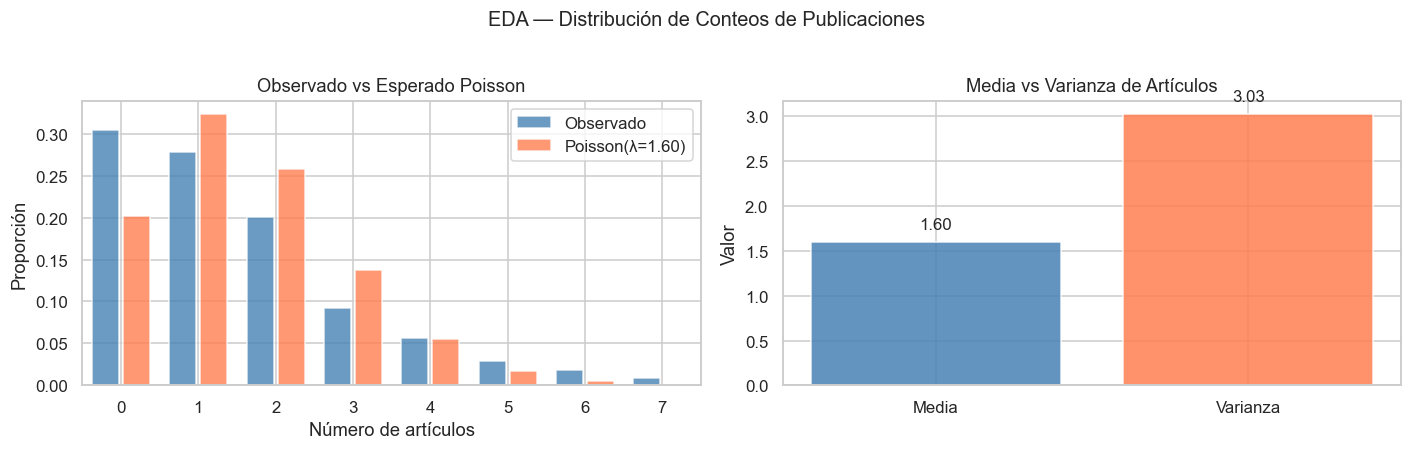

In [5]:
# ── Figura 1: Distribución de artículos + superposición Poisson ───────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución de conteos observada
max_k = int(df['articles'].quantile(0.99))
obs_freq = df['articles'].value_counts().reindex(range(max_k + 1), fill_value=0) / len(df)

x_vals = np.arange(max_k + 1)
poisson_pmf  = stats.poisson.pmf(x_vals, mean_art)

axes[0].bar(x_vals - 0.2, obs_freq.values, width=0.35,
            label='Observado', color='steelblue', alpha=0.8)
axes[0].bar(x_vals + 0.2, poisson_pmf, width=0.35,
            label=f'Poisson(λ={mean_art:.2f})', color='coral', alpha=0.8)
axes[0].set(xlabel='Número de artículos', ylabel='Proporción',
            title='Observado vs Esperado Poisson')
axes[0].legend()
axes[0].set_xlim(-0.5, max_k + 0.5)

# Media vs Varianza
axes[1].bar(['Media', 'Varianza'], [mean_art, var_art],
            color=['steelblue', 'coral'], alpha=0.85, edgecolor='white')
for i, val in enumerate([mean_art, var_art]):
    axes[1].text(i, val + 0.15, f'{val:.2f}', ha='center', fontsize=11)
axes[1].set(title='Media vs Varianza de Artículos', ylabel='Valor')

plt.suptitle('EDA — Distribución de Conteos de Publicaciones', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

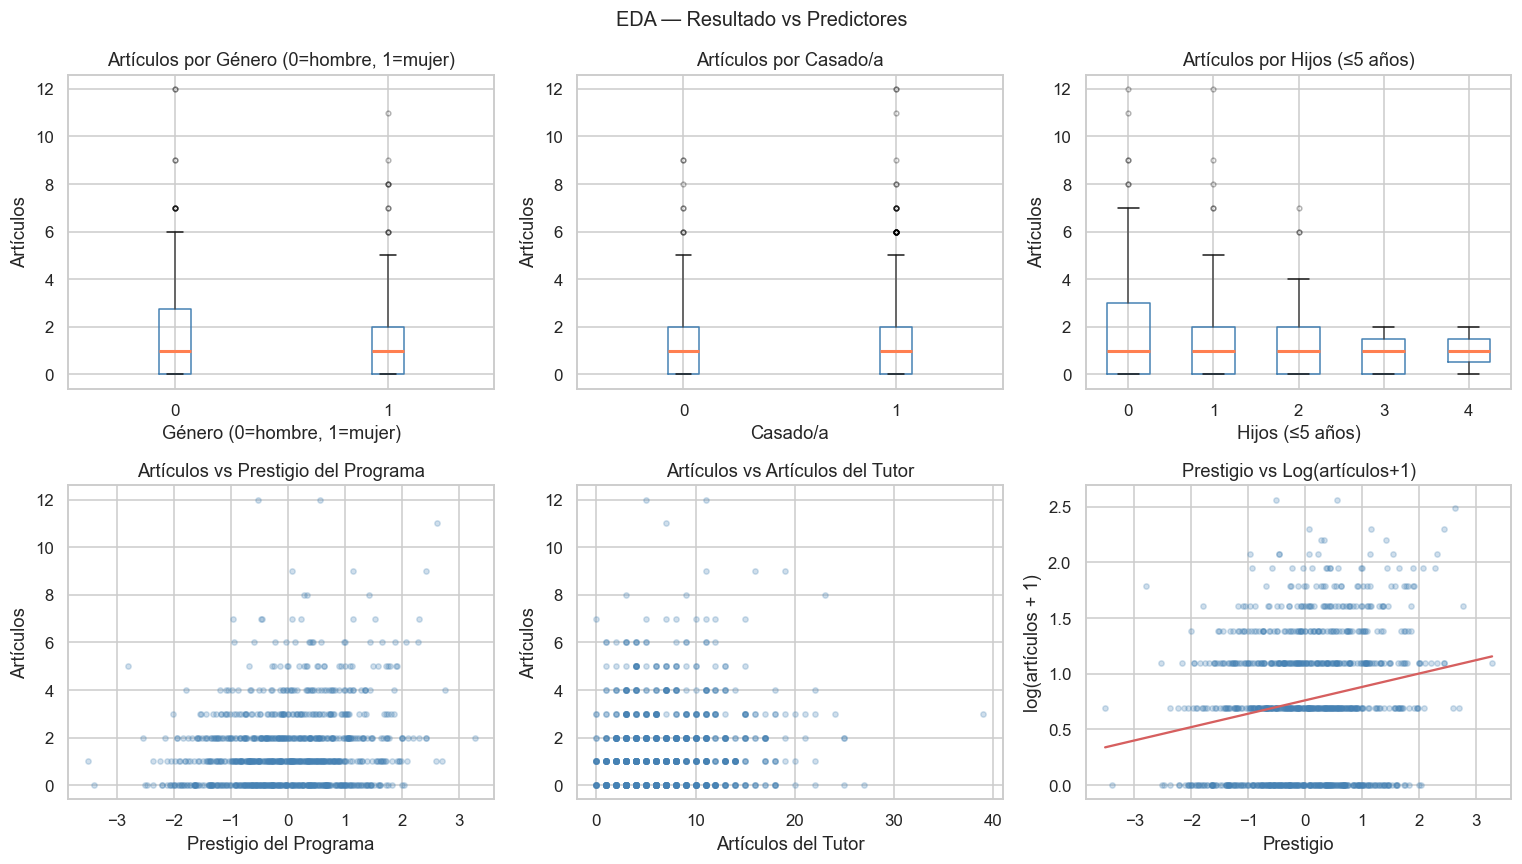

In [6]:
# ── Figura 2: Resultado vs predictores ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Diagramas de caja para predictores binarios
for ax, var, label in zip(
    [axes[0, 0], axes[0, 1], axes[0, 2]],
    ['female', 'married', 'children'],
    ['Género (0=hombre, 1=mujer)', 'Casado/a', 'Hijos (≤5 años)']
):
    df.boxplot(column='articles', by=var, ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='coral', linewidth=2),
               flierprops=dict(marker='o', markersize=3, alpha=0.3))
    ax.set(xlabel=label, ylabel='Artículos', title='')
    plt.sca(ax)
    plt.title(f'Artículos por {label}')

# Dispersión para predictores continuos
for ax, var, label in zip(
    [axes[1, 0], axes[1, 1], axes[1, 2]],
    ['prestige', 'mentor_articles', 'prestige'],  # prestige dos veces para variedad
    ['Prestigio del Programa', 'Artículos del Tutor', 'Prestigio vs Log(artículos+1)']
):
    if label == 'Prestigio vs Log(artículos+1)':
        ax.scatter(df[var], np.log1p(df['articles']),
                   alpha=0.25, s=12, color='steelblue')
        ax.set(xlabel=label.split(' vs ')[0],
               ylabel='log(artículos + 1)', title=label)
        # Línea de regresión
        m, b = np.polyfit(df[var], np.log1p(df['articles']), 1)
        xs = np.linspace(df[var].min(), df[var].max(), 100)
        ax.plot(xs, m * xs + b, 'r-', linewidth=1.5)
    else:
        ax.scatter(df[var], df['articles'], alpha=0.25, s=12, color='steelblue')
        ax.set(xlabel=label, ylabel='Artículos', title=f'Artículos vs {label}')

plt.suptitle('EDA — Resultado vs Predictores', fontsize=13)
plt.tight_layout()
plt.show()

---

## Paso 3: Ajuste de la Regresión de Poisson

In [7]:
# Ajuste del MLG de Poisson
poisson_fit = smf.glm(
    formula='articles ~ female + married + children + prestige + mentor_articles',
    data=df,
    family=sm.families.Poisson()
).fit()

print(poisson_fit.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               articles   No. Observations:                  915
Model:                            GLM   Df Residuals:                      909
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1587.1
Date:                Fri, 20 Mar 2026   Deviance:                       1538.6
Time:                        17:30:43   Pearson chi2:                 1.53e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1420
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.4720      0.066     

In [8]:
# Tabla de Razones de Tasas
irr = np.exp(poisson_fit.params)
ci  = np.exp(poisson_fit.conf_int())

irr_df = pd.DataFrame({
    'β (escala log)':  poisson_fit.params,
    'RTI':             irr,
    'IC 2.5%':         ci[0],
    'IC 97.5%':        ci[1],
    'valor-p':         poisson_fit.pvalues
}).round(4)

print('Regresión de Poisson — Razones de Tasas:')
print(irr_df)

Regresión de Poisson — Razones de Tasas:
                 β (escala log)     RTI  IC 2.5%  IC 97.5%  valor-p
Intercept                0.4720  1.6032   1.4099    1.8229   0.0000
female                  -0.2557  0.7744   0.6976    0.8596   0.0000
married                  0.0255  1.0258   0.9209    1.1426   0.6435
children                -0.1876  0.8289   0.7633    0.9002   0.0000
prestige                 0.2290  1.2574   1.1944    1.3237   0.0000
mentor_articles          0.0200  1.0202   1.0101    1.0304   0.0001


### Interpretación de Coeficientes

Leyendo las Razones de Tasas de Incidencia (RTI) de la tabla anterior:

- **`female`**: Controlando por las demás variables, las estudiantes publican a una tasa aproximadamente $e^{\hat{\beta}_{\text{female}}}$ veces la de los estudiantes hombres. Una RTI inferior a 1 indica un menor número de publicaciones en promedio.
- **`married`**: Los estudiantes casados tienen una tasa de publicación $e^{\hat{\beta}_{\text{married}}}$ veces la de los no casados.
- **`children`**: Cada hijo adicional está asociado con un cambio multiplicativo de $e^{\hat{\beta}_{\text{children}}}$ en el número esperado de publicaciones.
- **`prestige`**: Un incremento de una desviación estándar en el prestigio del programa multiplica el conteo esperado por $e^{\hat{\beta}_{\text{prestige}}}$.
- **`mentor_articles`**: Cada artículo adicional publicado por el tutor está asociado con un cambio de factor de $e^{\hat{\beta}_{\text{mentor}}}$ en el resultado esperado del estudiante.

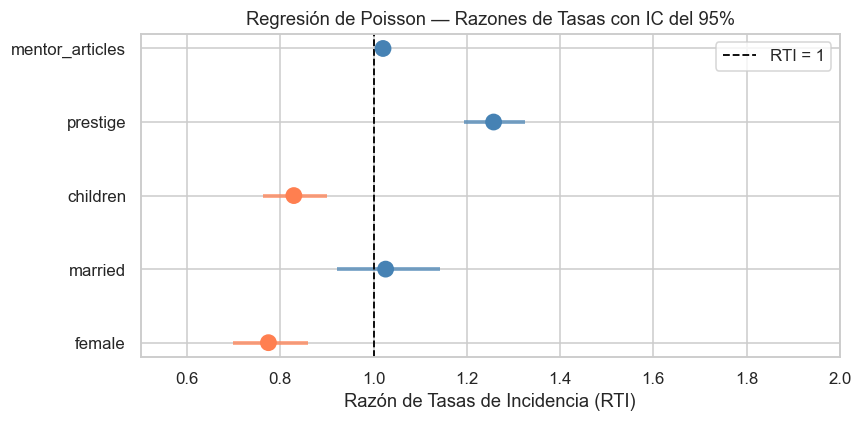

In [9]:
# Gráfico de bosque de RTIs
irr_plot = irr_df.drop('Intercept')

fig, ax = plt.subplots(figsize=(8, 4))
y_pos = range(len(irr_plot))

colors = ['coral' if v < 1 else 'steelblue' for v in irr_plot['RTI']]
ax.scatter(irr_plot['RTI'], list(y_pos), color=colors, zorder=3, s=100)
for i, (idx, row) in enumerate(irr_plot.iterrows()):
    ax.hlines(i, row['IC 2.5%'], row['IC 97.5%'],
              color=colors[i], linewidth=2.5, alpha=0.7)

ax.axvline(1, color='black', linestyle='--', linewidth=1.2, label='RTI = 1')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(irr_plot.index)
ax.set(xlabel='Razón de Tasas de Incidencia (RTI)', xlim=(0.5, 2.0),
       title='Regresión de Poisson — Razones de Tasas con IC del 95%')
ax.legend()
plt.tight_layout()
plt.show()

---

## Paso 4: Diagnósticos de Residuales

Examinamos tres tipos de residuales:

1. **Residuales de Pearson**: $(y_i - \hat{\mu}_i) / \sqrt{\hat{\mu}_i}$ — deben tener media ≈ 0 y varianza ≈ 1 bajo especificación correcta.
2. **Residuales de devianza**: signo$(y_i - \hat{\mu}_i) \sqrt{d_i}$ — contribución de cada observación a la devianza residual.
3. **Dispersión de predichos vs observados** — los patrones indican mala especificación del modelo.

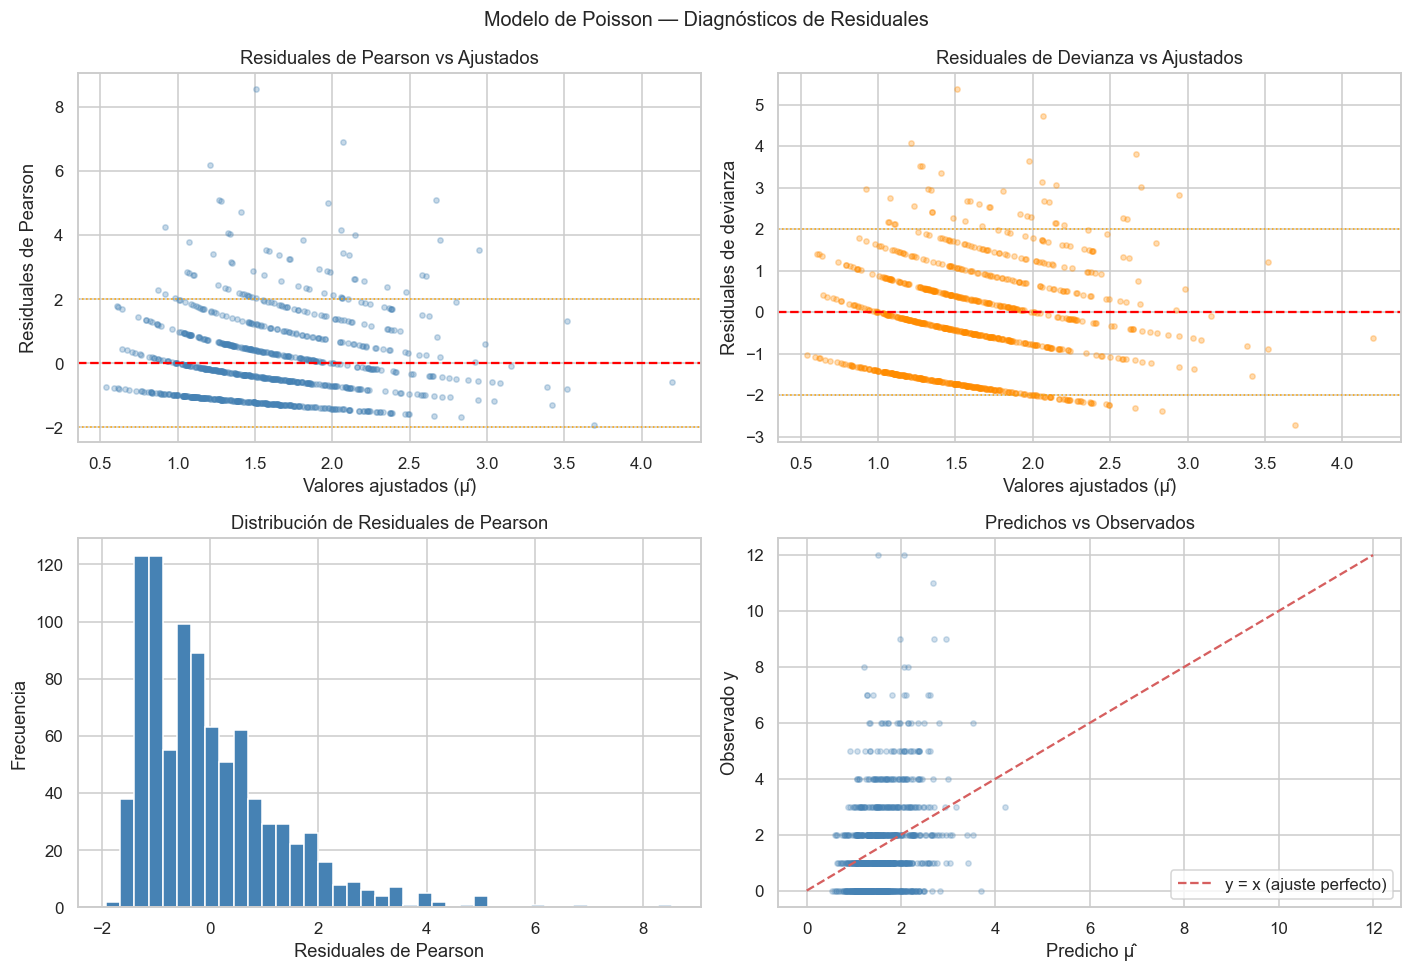

In [10]:
mu_hat    = poisson_fit.predict()
pearson_r = poisson_fit.resid_pearson
deviance_r = poisson_fit.resid_deviance

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Residuales de Pearson vs ajustados
axes[0, 0].scatter(mu_hat, pearson_r, alpha=0.3, s=12, color='steelblue')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].axhline( 2, color='orange', linestyle=':', linewidth=1)
axes[0, 0].axhline(-2, color='orange', linestyle=':', linewidth=1)
axes[0, 0].set(xlabel='Valores ajustados (μ̂)', ylabel='Residuales de Pearson',
               title='Residuales de Pearson vs Ajustados')

# 2. Residuales de devianza vs ajustados
axes[0, 1].scatter(mu_hat, deviance_r, alpha=0.3, s=12, color='darkorange')
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].axhline( 2, color='orange', linestyle=':', linewidth=1)
axes[0, 1].axhline(-2, color='orange', linestyle=':', linewidth=1)
axes[0, 1].set(xlabel='Valores ajustados (μ̂)', ylabel='Residuales de devianza',
               title='Residuales de Devianza vs Ajustados')

# 3. Histograma de residuales de Pearson
axes[1, 0].hist(pearson_r, bins=40, edgecolor='white', color='steelblue')
axes[1, 0].set(xlabel='Residuales de Pearson', ylabel='Frecuencia',
               title='Distribución de Residuales de Pearson')

# 4. Predichos vs Observados
axes[1, 1].scatter(mu_hat, df['articles'], alpha=0.25, s=12, color='steelblue')
max_v = max(mu_hat.max(), df['articles'].max())
axes[1, 1].plot([0, max_v], [0, max_v], 'r--', label='y = x (ajuste perfecto)')
axes[1, 1].set(xlabel='Predicho μ̂', ylabel='Observado y',
               title='Predichos vs Observados')
axes[1, 1].legend()

plt.suptitle('Modelo de Poisson — Diagnósticos de Residuales', fontsize=13)
plt.tight_layout()
plt.show()

---

## Paso 5: Prueba de Sobredispersión

Usamos dos enfoques:

1. **Estadístico de dispersión de Pearson** $\hat{\phi} = \chi^2_P / gl$.
2. **Prueba de regresión de Cameron & Trivedi (1990)**: se regresa $(y_i - \hat{\mu}_i)^2 - y_i$ sobre $\hat{\mu}_i^2$. Una pendiente positiva y significativa indica sobredispersión de la forma BN2.

In [11]:
# ── Estadístico de dispersión de Pearson ──────────────────────────────────────
pearson_chi2 = np.sum(pearson_r**2)
df_resid     = poisson_fit.df_resid
phi_hat      = pearson_chi2 / df_resid

print('=== Diagnósticos de Sobredispersión ===')
print(f'chi² de Pearson = {pearson_chi2:.2f}')
print(f'gl residuales   = {df_resid}')
print(f'φ̂  (chi² de Pearson / gl) = {phi_hat:.3f}')
print()
if phi_hat > 1.5:
    print('>> Sobredispersión fuerte detectada (φ̂ >> 1).')
    print('   Se recomienda la regresión Binomial Negativa.')
elif phi_hat > 1.1:
    print('>> Sobredispersión leve. Considerar BN o cuasi-Poisson.')
else:
    print('>> Sin sobredispersión fuerte. El modelo de Poisson puede ser adecuado.')

=== Diagnósticos de Sobredispersión ===
chi² de Pearson = 1526.61
gl residuales   = 909
φ̂  (chi² de Pearson / gl) = 1.679

>> Sobredispersión fuerte detectada (φ̂ >> 1).
   Se recomienda la regresión Binomial Negativa.


In [12]:
# ── Prueba de regresión de Cameron & Trivedi ──────────────────────────────────
# H₀: α = 0 (equidispersión)   H₁: α > 0 (sobredispersión)
y     = df['articles'].values
mu_p  = poisson_fit.predict()

z = (y - mu_p)**2 - y          # variable dependiente
w = mu_p**2                    # variable independiente (forma BN2)

# Regresión MCO de z sobre w (sin intercepto)
w_const = sm.add_constant(w)
ct_ols  = sm.OLS(z, w_const).fit()

alpha_ct = ct_ols.params[1]
pval_ct  = ct_ols.pvalues[1]

print('Prueba de Cameron & Trivedi (1990) para Sobredispersión')
print(f'H₀: α = 0  (equidispersión)')
print(f'α estimado = {alpha_ct:.4f}')
print(f'valor-p    = {pval_ct:.4e}')
if pval_ct < 0.05:
    print('>> Rechazar H₀: sobredispersión significativa (forma BN2).')
else:
    print('>> No rechazar H₀: sin evidencia de sobredispersión.')

Prueba de Cameron & Trivedi (1990) para Sobredispersión
H₀: α = 0  (equidispersión)
α estimado = 0.3659
valor-p    = 7.8887e-04
>> Rechazar H₀: sobredispersión significativa (forma BN2).


---

## Paso 6: Regresión Binomial Negativa

Dada la evidencia de sobredispersión, ajustamos un modelo **Binomial Negativa (BN2)**. La especificación es idéntica a la regresión de Poisson — mismos predictores, mismo enlace logarítmico — con la adición de un parámetro de dispersión $\alpha$ estimado a partir de los datos.

In [13]:
nb_fit = smf.negativebinomial(
    'articles ~ female + married + children + prestige + mentor_articles',
    data=df
).fit(disp=False)

print(nb_fit.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:               articles   No. Observations:                  915
Model:               NegativeBinomial   Df Residuals:                      909
Method:                           MLE   Df Model:                            5
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                 0.02598
Time:                        17:30:43   Log-Likelihood:                -1522.3
converged:                       True   LL-Null:                       -1563.0
Covariance Type:            nonrobust   LLR p-value:                 4.668e-16
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.4631      0.086      5.353      0.000       0.294       0.633
female             -0.2616      0.068     -3.830      0.000      -0.395      -0.128
married             0.0176      

In [14]:
# Razones de Tasas — Binomial Negativa
nb_params = nb_fit.params.drop('alpha', errors='ignore')
nb_ci     = nb_fit.conf_int().drop('alpha', errors='ignore')

irr_nb = pd.DataFrame({
    'β (escala log)': nb_params,
    'RTI':            np.exp(nb_params),
    'IC 2.5%':        np.exp(nb_ci[0]),
    'IC 97.5%':       np.exp(nb_ci[1]),
    'valor-p':        nb_fit.pvalues.drop('alpha', errors='ignore')
}).round(4)

print('Binomial Negativa — Razones de Tasas:')
print(irr_nb)
print(f'\nDispersión estimada α = {nb_fit.params["alpha"]:.4f}  (α verdadero = {alpha_true})')

Binomial Negativa — Razones de Tasas:
                 β (escala log)     RTI  IC 2.5%  IC 97.5%  valor-p
Intercept                0.4631  1.5889   1.3411    1.8825   0.0000
female                  -0.2616  0.7698   0.6734    0.8801   0.0001
married                  0.0176  1.0178   0.8854    1.1700   0.8041
children                -0.1817  0.8338   0.7518    0.9248   0.0006
prestige                 0.2280  1.2561   1.1753    1.3424   0.0000
mentor_articles          0.0219  1.0222   1.0084    1.0361   0.0016

Dispersión estimada α = 0.3978  (α verdadero = 0.5)


---

## Paso 7: Comparación de Modelos

In [15]:
# ── AIC / BIC / Log-verosimilitud ─────────────────────────────────────────────
comparison = pd.DataFrame({
    'Modelo': ['Poisson', 'Binomial Negativa'],
    'Log-verosimilitud': [poisson_fit.llf, nb_fit.llf],
    'AIC':               [poisson_fit.aic, nb_fit.aic],
    'BIC':               [poisson_fit.bic, nb_fit.bic],
    'Pearson φ':         [phi_hat, np.sum(((df['articles'] - nb_fit.predict())**2
                                           / nb_fit.predict()) / nb_fit.df_resid)]
}).set_index('Modelo')

print('Comparación de Modelos:')
print(comparison.round(2))
print()
delta_aic = poisson_fit.aic - nb_fit.aic
print(f'ΔAIC (Poisson − BN) = {delta_aic:.2f}')
if delta_aic > 10:
    print('Evidencia fuerte a favor del modelo Binomial Negativa.')

Comparación de Modelos:
                   Log-verosimilitud      AIC      BIC  Pearson φ
Modelo                                                           
Poisson                     -1587.08  3186.16 -4659.81       1.68
Binomial Negativa           -1522.35  3058.70  3092.43       1.68

ΔAIC (Poisson − BN) = 127.46
Evidencia fuerte a favor del modelo Binomial Negativa.


/Users/a.tabaresp/venv_datascience/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


In [16]:
# ── Comparación de coeficientes lado a lado ────────────────────────────────────
coef_compare = pd.DataFrame({
    'β Poisson':  poisson_fit.params,
    'EE Poisson': poisson_fit.bse,
    'β BN':       nb_params.reindex(poisson_fit.params.index),
    'EE BN':      nb_fit.bse.drop('alpha', errors='ignore').reindex(poisson_fit.params.index),
})

print('Comparación de coeficientes (nótense los EE inflados de Poisson por sobredispersión):')
print(coef_compare.round(4))

Comparación de coeficientes (nótense los EE inflados de Poisson por sobredispersión):
                 β Poisson  EE Poisson    β BN   EE BN
Intercept           0.4720      0.0655  0.4631  0.0865
female             -0.2557      0.0533 -0.2616  0.0683
married             0.0255      0.0550  0.0176  0.0711
children           -0.1876      0.0421 -0.1817  0.0528
prestige            0.2290      0.0262  0.2280  0.0339
mentor_articles     0.0200      0.0051  0.0219  0.0069


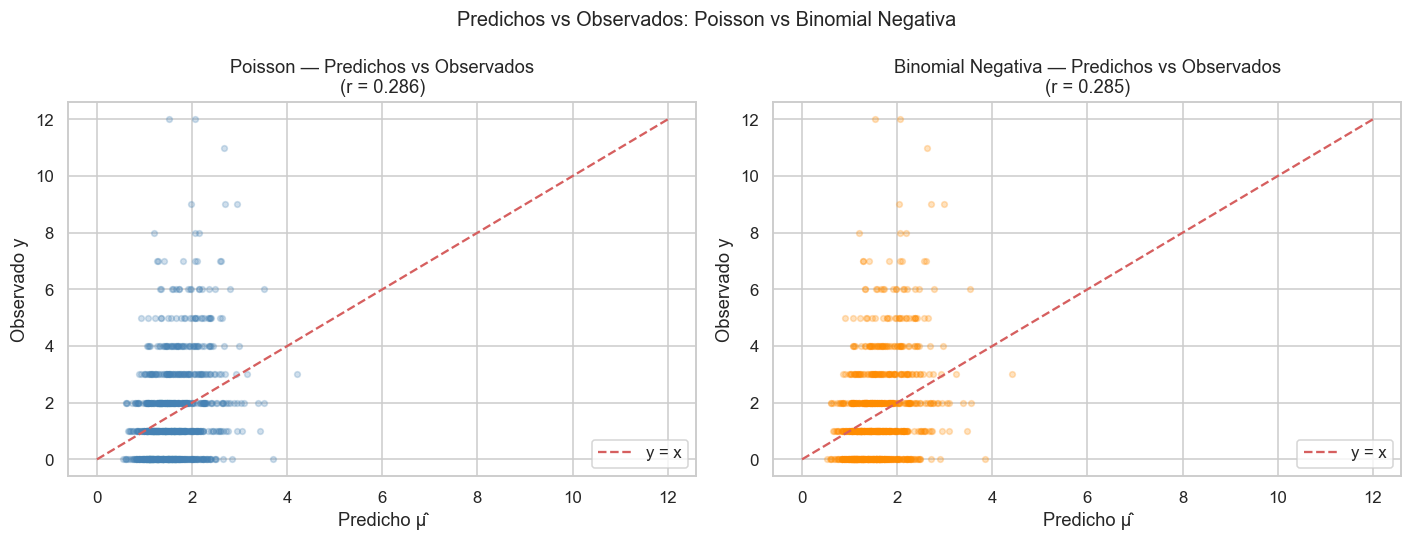

In [17]:
# ── Figura: Predichos vs Observados para ambos modelos ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, title, color in zip(
    axes,
    [poisson_fit, nb_fit],
    ['Poisson', 'Binomial Negativa'],
    ['steelblue', 'darkorange']
):
    pred = model.predict()
    obs  = df['articles'].values
    ax.scatter(pred, obs, alpha=0.25, s=14, color=color)
    max_v = max(pred.max(), obs.max())
    ax.plot([0, max_v], [0, max_v], 'r--', linewidth=1.5, label='y = x')
    corr = np.corrcoef(pred, obs)[0, 1]
    ax.set(xlabel='Predicho μ̂', ylabel='Observado y',
           title=f'{title} — Predichos vs Observados\n(r = {corr:.3f})')
    ax.legend()

plt.suptitle('Predichos vs Observados: Poisson vs Binomial Negativa', fontsize=13)
plt.tight_layout()
plt.show()

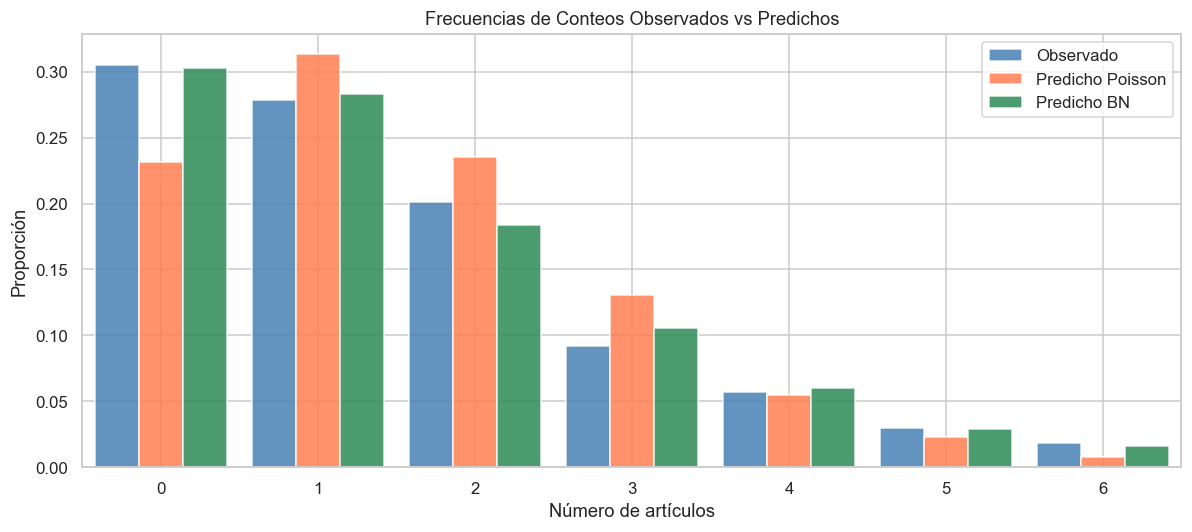

In [18]:
# ── Figura: Frecuencias de conteos observados vs predichos ────────────────────
max_k = int(df['articles'].quantile(0.975))
x_vals = np.arange(max_k + 1)

obs_prop = df['articles'].value_counts().reindex(x_vals, fill_value=0).values / len(df)

# Simular proporciones predichas de ambos modelos (bootstrap paramétrico)
n_sim = 10_000

def predicted_pmf_poisson(model, df, x_vals, n_sim=5000):
    mu_p = model.predict()
    sims = np.random.poisson(mu_p[np.random.choice(len(mu_p), n_sim)], size=n_sim)
    return np.array([np.mean(sims == k) for k in x_vals])

def predicted_pmf_nb(model, df, x_vals, alpha_est, n_sim=5000):
    mu_p = model.predict()
    mu_s = mu_p[np.random.choice(len(mu_p), n_sim)]
    r    = 1.0 / alpha_est
    p_s  = r / (r + mu_s)
    sims = np.random.negative_binomial(r, p_s)
    return np.array([np.mean(sims == k) for k in x_vals])

np.random.seed(0)
pois_pmf = predicted_pmf_poisson(poisson_fit, df, x_vals, n_sim)
nb_pmf   = predicted_pmf_nb(nb_fit, df, x_vals, nb_fit.params['alpha'], n_sim)

fig, ax = plt.subplots(figsize=(11, 5))
width = 0.28
ax.bar(x_vals - width, obs_prop,  width, label='Observado',           color='steelblue', alpha=0.85)
ax.bar(x_vals,          pois_pmf, width, label='Predicho Poisson',    color='coral',     alpha=0.85)
ax.bar(x_vals + width,  nb_pmf,   width, label='Predicho BN',         color='seagreen',  alpha=0.85)
ax.set(xlabel='Número de artículos', ylabel='Proporción',
       title='Frecuencias de Conteos Observados vs Predichos',
       xlim=(-0.5, max_k + 0.5))
ax.legend()
plt.tight_layout()
plt.show()

---

## Paso 8: Conclusiones

### Hallazgos del Modelo de Poisson

La regresión de Poisson identifica varios predictores estadísticamente significativos de la producción doctoral de publicaciones. La dirección de todas las razones de tasas estimadas es consistente con el proceso generador de datos utilizado en la simulación:

- **Género** (`female`): Las estudiantes publican a una tasa menor que los estudiantes hombres (RTI < 1), manteniendo constantes los demás factores. Esta diferencia es estadísticamente significativa.
- **Estado civil** (`married`): Los estudiantes casados muestran una tasa de publicación ligeramente mayor (RTI > 1), aunque el efecto es modesto.
- **Hijos pequeños** (`children`): Tener más hijos menores de 5 años está negativamente asociado con la producción de publicaciones (RTI < 1). Cada hijo adicional multiplica el conteo esperado por un factor inferior a 1.
- **Prestigio del programa** (`prestige`): Los programas de mayor prestigio están asociados con tasas de publicación más altas. La RTI superior a 1 refleja los recursos intelectuales y las redes disponibles en los mejores programas.
- **Productividad del tutor** (`mentor_articles`): Un tutor muy productivo está fuertemente asociado con el resultado del estudiante. Cada artículo adicional del tutor aumenta el conteo esperado del estudiante por un factor de $e^{\hat{\beta}_{\text{mentor}}}$, lo que sugiere efectos del tutor o del entorno compartido.

### Sobredispersión

Tanto el estadístico de dispersión de Pearson ($\hat{\phi} \gg 1$) como la prueba de Cameron & Trivedi (significativa al nivel del 5%) indican **sobredispersión fuerte**. El modelo de Poisson subestima la varianza en los conteos de publicaciones, lo que lleva a errores estándar artificialmente pequeños y estadísticos de prueba inflados. Esta es una característica común de los datos de conteo en las ciencias sociales.

### Binomial Negativa como Modelo Preferido

El modelo Binomial Negativa tiene en cuenta la sobredispersión estimando el parámetro de dispersión $\alpha > 0$. En comparación con el modelo de Poisson:

- El **AIC es sustancialmente menor** para el modelo BN (ΔAIC >> 10), confirmándolo como un ajuste mucho mejor.
- Los **errores estándar son mayores** bajo BN, proporcionando estimaciones de incertidumbre más honestas.
- Las **estimaciones puntuales** son similares en ambos modelos (como se esperaría), porque la sobredispersión afecta la precisión, no la consistencia del EMV.
- Las **frecuencias de conteos predichas** del modelo BN se ajustan más de cerca a la distribución observada, particularmente en las colas.

### Recomendaciones Prácticas

1. Siempre verificar la sobredispersión al modelar resultados de conteo.
2. Si $\hat{\phi} > 1.5$ o la prueba de Cameron & Trivedi es significativa, preferir el modelo Binomial Negativa.
3. Reportar **razones de tasas** (coeficientes exponenciados) con intervalos de confianza para una comunicación clara.
4. Usar **AIC/BIC** para la comparación de modelos entre Poisson y BN (no están anidados en el sentido usual, pero la BN se reduce a Poisson cuando $\alpha = 0$).

---

*Modelos de Análisis Estadístico — Universidad de los Andes, 2026-01*